#**A. Pendahuluan**

###**Deskripsi Dataset**

Dataset ini berisi data terkait hotel, menjelaskan tentang dua dataset yang berisi informasi permintaan hotel. Dataset pertama berasal dari sebuah hotel resor (H1), sedangkan dataset kedua berasal dari hotel kota (H2). Keduanya memiliki struktur data yang sama, terdiri dari 31 variabel yang menggambarkan 40.060 entri pemesanan pada H1 dan 79.330 entri pemesanan pada H2. Setiap baris dalam dataset merepresentasikan satu pemesanan hotel. Pemesanan dengan tanggal kedatangan antara 1 Juli 2015 hingga 31 Agustus 2017, baik pemesanan yang benar-benar terealisasi maupun yang kemudian dibatalkan. Karena dataset ini menggunakan data hotel yang bersifat nyata, seluruh informasi yang dapat mengungkap identitas hotel atau tamu telah dihapus untuk menjaga privasi.





###**Alasan Dataset Menarik**

1.   Data Asli

Dataset ini menggunakan data pemesanan hotel yang benar-benar terjadi, hal ini membuat analisis yang dilakukan menjadi lebih relevan terhadap kondisi bisnis perhotelan sebenarnya.

2.   Ukuran Data

Dengan lebih dari 119.000 pemesanan (gabungan H1 dan H2), dataset ini memungkinkan analisis statistik yang kuat, pengujian model prediktif yang stabil, dan eksplorasi pola yang lebih akurat

3. Variabel lengkap dan beragam

Dataset memiliki 31 fitur yang meliputi:

*   Tanggal kedatangan
*   Lama menginap
*   Jumlah tamu
*   Jenis kamar
*   Harga kamar (ADR)
*   Segmen pasar
*   Status pembatalan
*   Permintaan khusus
*   dan lainnya

Keragaman fitur ini membuka banyak jenis analisis dan model prediktif


###**Pertanyaan/ Tujuan Analisis**

Tujuan utama dari analisis ini adalah untuk memahami faktor-faktor yang mempengaruhi status pembatalan pemesanan, pola lama menginap dan kunjungan musiman, serta bagaimana channel booking dan harga berkaitan dengan demand hotel.

Adapun pertanyaan yang ingin dijawab dari dataset ini adalah:

1. Faktor apa saja yang paling berkontribusi terhadap pembatalan (cancellation) booking hotel?

2. Bagaimana pola seasonal dari pemesanan hotel sepanjang tahun? Kapan periode peak season terjadi?

3. Berapa rata-rata lama menginap customer berdasarkan tipe hotel dan segmen customer?

4. Channel pemesanan mana yang paling banyak digunakan, dan apakah channel tertentu memiliki tingkat cancellation lebih tinggi?

5. Bagaimana tren harga (ADR) berubah terhadap jumlah booking? Apakah ADR cenderung meningkat saat demand tinggi?

#**B. Setup & Package**

###**Semua Import di bagian atas Notebook**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_wine, load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import (SelectKBest, chi2, f_classif, mutual_info_classif, RFE)
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA, KernelPCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns
import plotly.express as px
import os


###**Path File Disimpan dalam Variabel**

In [ ]:
path = 'data/raw.csv'

###**Penjelasan Singkat Fungsi Paket**

Berikut adalah penjelasan singkat untuk fungsi setiap paket yang Anda sebutkan:

1. **`pandas`**: Untuk manipulasi dan analisis data, terutama struktur data seperti DataFrame dan Series.

2. **`numpy`**: Untuk operasi matematika dan array multidimensi, seperti array numerik dan matriks.

3. **`matplotlib.pyplot`**: Untuk membuat visualisasi data dalam bentuk plot 2D, seperti grafik garis, histogram, scatter plot, dll.

4. **`sklearn.datasets` (load_breast_cancer, load_wine, load_iris)**: Mengimpor dataset standar dari `scikit-learn` yang digunakan untuk eksperimen dan benchmarking model machine learning. Dataset yang disebutkan adalah:

     * `load_breast_cancer`: Dataset klasifikasi kanker payudara.
     * `load_wine`: Dataset klasifikasi jenis anggur.
     * `load_iris`: Dataset klasifikasi bunga iris.

5. **`sklearn.model_selection` (cross_val_score, StratifiedKFold, train_test_split)**:

   * `cross_val_score`: Untuk melakukan validasi silang (cross-validation) pada model.
   * `StratifiedKFold`: Pembagian data dalam K fold dengan menjaga proporsi kelas yang seimbang.
   * `train_test_split`: Untuk membagi dataset menjadi data pelatihan dan pengujian.

6. **`sklearn.preprocessing` (StandardScaler, MinMaxScaler, PowerTransformer)**:

   * `StandardScaler`: Untuk menstandarkan data (mean = 0, variance = 1).
   * `MinMaxScaler`: Untuk menskalakan data dalam rentang [0, 1].
   * `PowerTransformer`: Untuk mentransformasi data dengan distribusi lebih mendekati normal (normalisasi).

7. **`sklearn.feature_selection` (SelectKBest, chi2, f_classif, mutual_info_classif, RFE)**:

   * `SelectKBest`: Untuk memilih fitur terbaik berdasarkan skor tes tertentu.
   * `chi2`: Tes statistik Chi-squared untuk fitur kategorikal.
   * `f_classif`: Tes ANOVA untuk memilih fitur berdasarkan variansi antar kelas.
   * `mutual_info_classif`: Mengukur informasi saling terkait antar fitur dan kelas.
   * `RFE`: Recursive Feature Elimination, untuk menghapus fitur yang kurang penting secara iteratif.

8. **`sklearn.linear_model` (LogisticRegression, LassoCV)**:

   * `LogisticRegression`: Untuk model klasifikasi berbasis regresi logistik.
   * `LassoCV`: Regresi Lasso dengan cross-validation untuk pemilihan fitur.

9. **`sklearn.ensemble` (RandomForestClassifier)**:

   * `RandomForestClassifier`: Model ensemble yang menggunakan banyak pohon keputusan untuk klasifikasi.

10. **`sklearn.svm` (SVC)**:

    * `SVC`: Support Vector Classification, untuk klasifikasi menggunakan Support Vector Machines.

11. **`sklearn.decomposition` (PCA, KernelPCA)**:

    * `PCA`: Principal Component Analysis, teknik reduksi dimensi untuk mengekstraksi fitur utama.
    * `KernelPCA`: PCA dengan kernel untuk mengatasi data yang tidak linier.

12. **`sklearn.pipeline` (Pipeline, make_pipeline)**:

    * `Pipeline`: Membuat pipeline yang menggabungkan beberapa langkah seperti preprocessing dan model.
    * `make_pipeline`: Membuat pipeline dengan urutan langkah otomatis.

13. **`sklearn.metrics` (accuracy_score)**:

    * `accuracy_score`: Menghitung akurasi dari model klasifikasi.

14. **`sklearn.compose` (ColumnTransformer)**:

    * `ColumnTransformer`: Untuk menerapkan preprocessing berbeda pada subset kolom dalam data.

15. **`sklearn.impute` (SimpleImputer)**:

    * `SimpleImputer`: Untuk mengisi nilai yang hilang dalam dataset dengan teknik imputation, seperti mengganti nilai hilang dengan rata-rata atau modus.

16. **`seaborn`**: Untuk visualisasi data berbasis statistik yang lebih estetis dan lebih mudah digunakan dibandingkan dengan matplotlib, seperti heatmap, boxplot, pairplot, dll.

17. **`plotly.express`**: Untuk membuat visualisasi interaktif seperti grafik garis, histogram, scatter plot, dll. Lebih fokus pada interaktivitas dan visualisasi berbasis web.

Semua paket ini sangat berguna untuk **preprocessing data**, **pembangunan model machine learning**, **evaluasi model**, dan **visualisasi hasil**.


#**C. Data Preparation**

###**Import Dataset**

In [ ]:
df = pd.read_csv(path)
display(df)
print(df.shape)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


(119390, 32)


###**Langkah Cleaning dan Data Wrangling dengan Penjelasan Markdown**

In [ ]:
print("\nInfo Struktur Data")
print(df.info())


Info Struktur Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 

In [ ]:
print("Nilai Unik Semua Kolom")
for col in df.columns:
    print(f"{col}")
    print(df[col].unique())
    print(f"Total nilai unik: {df[col].nunique()}")
    print()

Nilai Unik Semua Kolom
hotel
['Resort Hotel' 'City Hotel']
Total nilai unik: 2

is_canceled
[0 1]
Total nilai unik: 2

lead_time
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200

In [ ]:
# Memeriksa Ringkasan Statistika dan Data Numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [ ]:
# Mengganti tipe data kolom yang diperlukan
cat_cols = ['hotel', 'arrival_date_month', 'meal','country','market_segment','distribution_channel','reserved_room_type','assigned_room_type','deposit_type','customer_type','reservation_status']
for col in cat_cols:
  df[col] = df[col].astype(str).str.strip()
  df[col] = df[col].astype('category')

In [ ]:
# Cek tipe data
df.dtypes

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
# Memeriksa missing value pada dataset
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


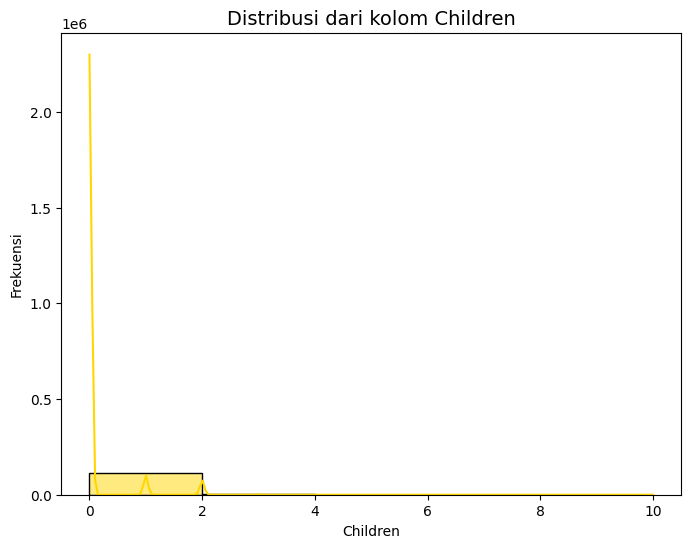

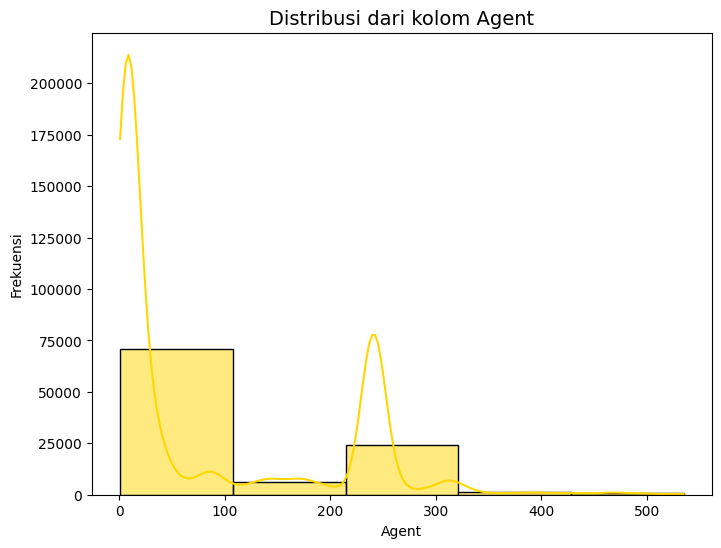

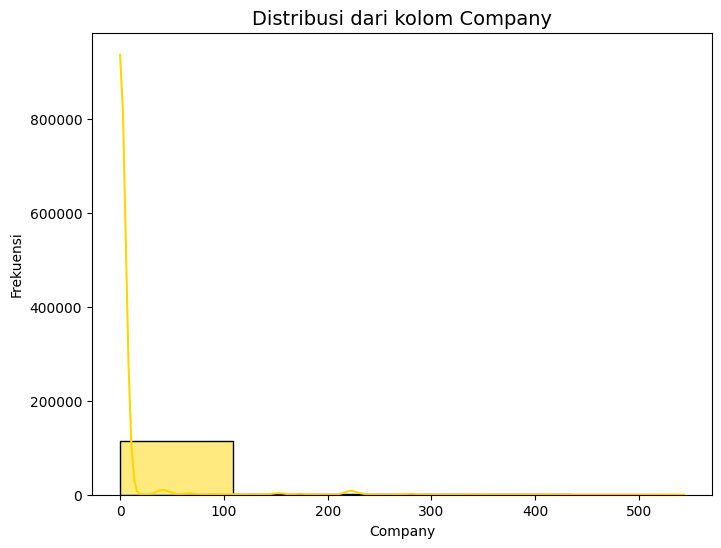

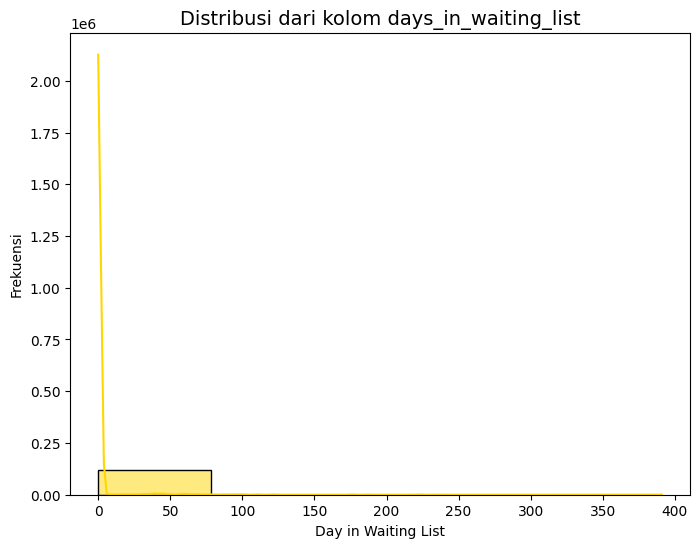

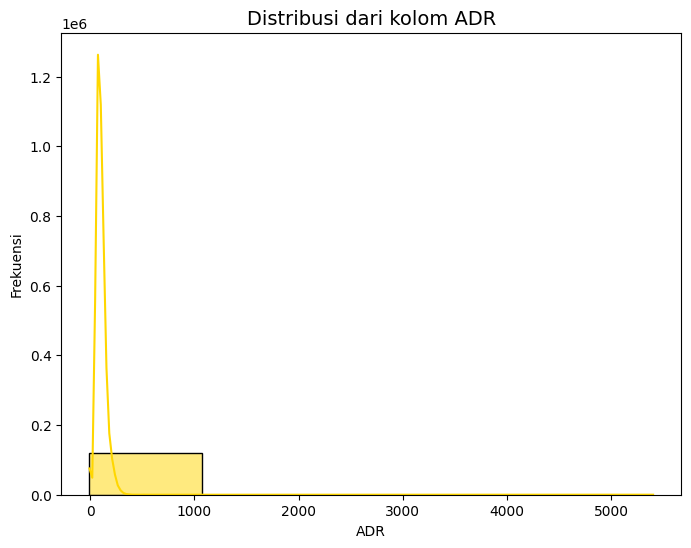

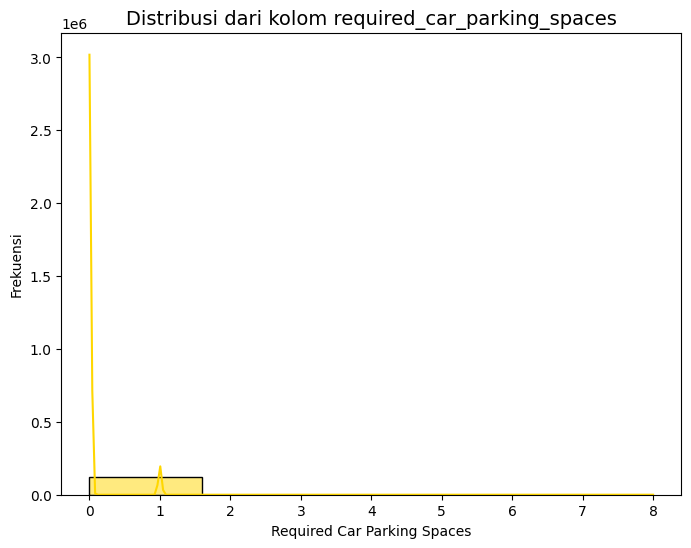

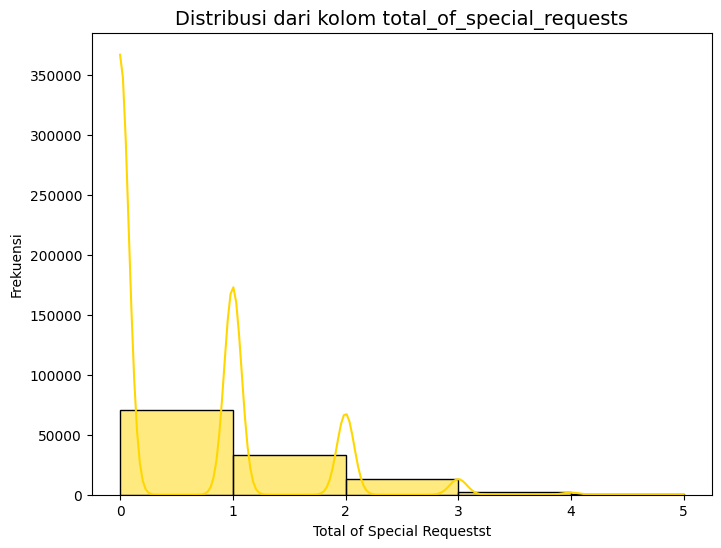

In [ ]:
df['company'] = pd.to_numeric(df['company'], errors='coerce').fillna(0)

# Cek distribusi missing value kolom children
plt.figure(figsize=(8,6))
sns.histplot(df['children'], bins=5, kde=True, color='gold')
plt.xlabel('Children')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Children', fontsize=14)
plt.show()

# Cek distribusi missing value kolom agent
plt.figure(figsize=(8,6))
sns.histplot(df['agent'], bins=5, kde=True, color='gold')
plt.xlabel('Agent')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Agent', fontsize=14)
plt.show()

# Cek distribusi missing value kolom company
plt.figure(figsize=(8,6))
sns.histplot(df['company'], bins=5, kde=True, color='gold')
plt.xlabel('Company')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Company', fontsize=14)
plt.show()

# Cek distribusi missing value kolom day_in_waiting_list
plt.figure(figsize=(8,6))
sns.histplot(df['days_in_waiting_list'], bins=5, kde=True, color='gold') # Corrected column name
plt.xlabel('Day in Waiting List')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom days_in_waiting_list', fontsize=14)
plt.show()

# Cek distribusi missing value kolom adr
plt.figure(figsize=(8,6))
sns.histplot(df['adr'], bins=5, kde=True, color='gold')
plt.xlabel('ADR')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom ADR', fontsize=14)
plt.show()

# Cek distribusi missing value kolom required_car_parking_spaces
plt.figure(figsize=(8,6))
sns.histplot(df['required_car_parking_spaces'], bins=5, kde=True, color='gold')
plt.xlabel('Required Car Parking Spaces')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom required_car_parking_spaces', fontsize=14)
plt.show()

# Cek distribusi missing value kolom total_of_special_requests
plt.figure(figsize=(8,6))
sns.histplot(df['total_of_special_requests'], bins=5, kde=True, color='gold')
plt.xlabel('Total of Special Requestst')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom total_of_special_requests', fontsize=14)
plt.show()

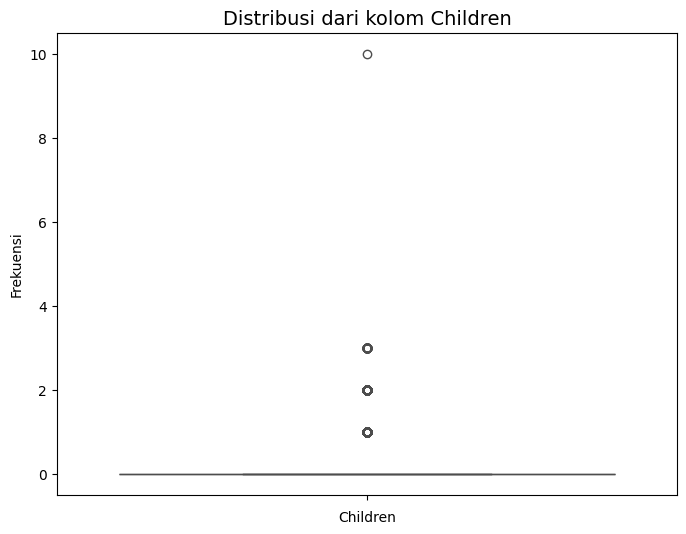

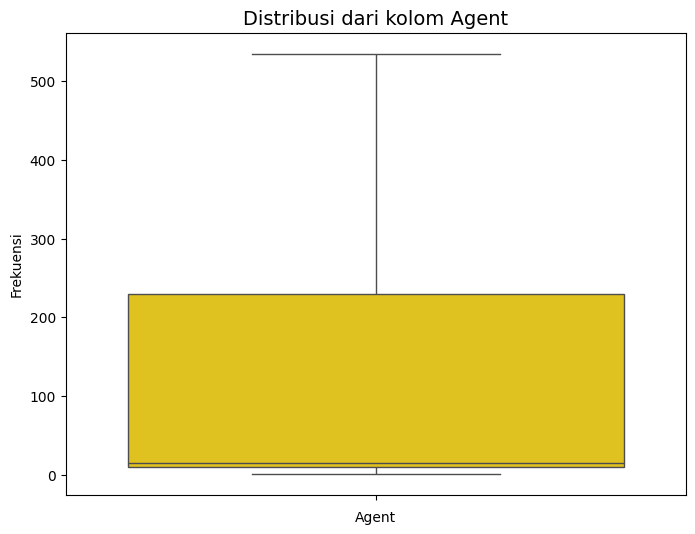

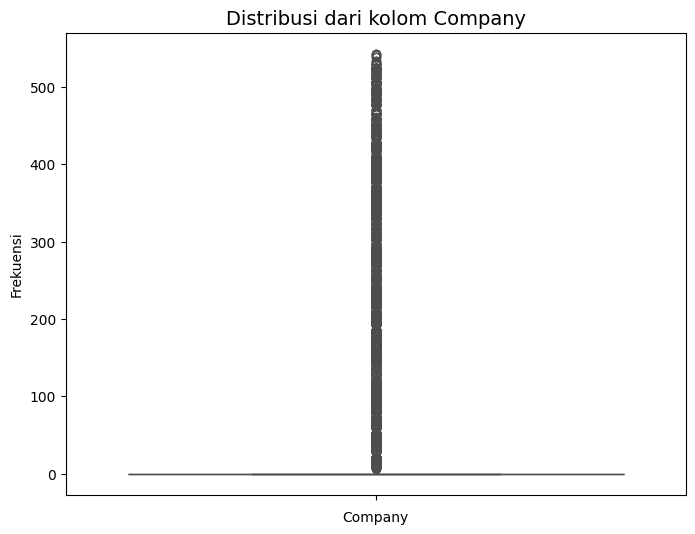

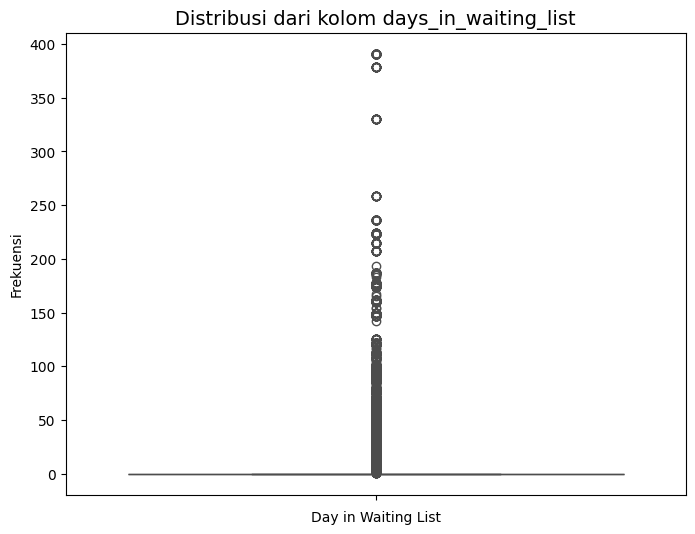

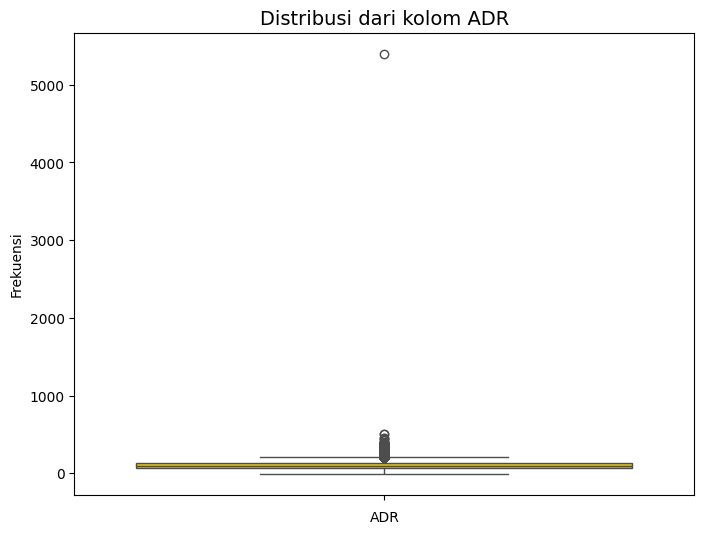

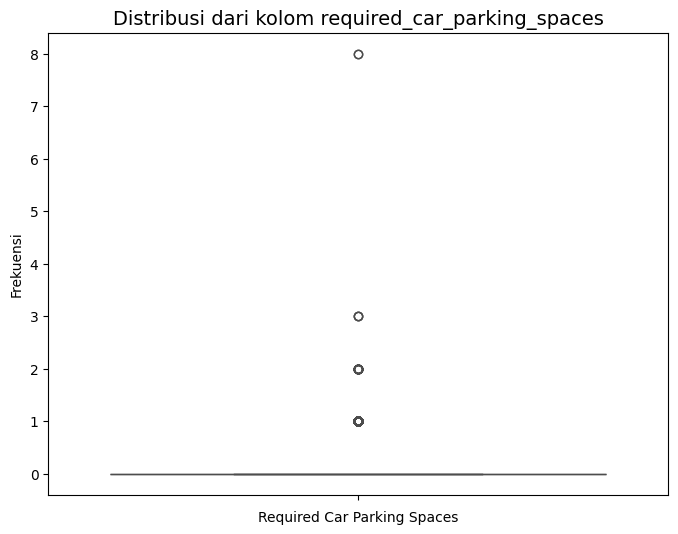

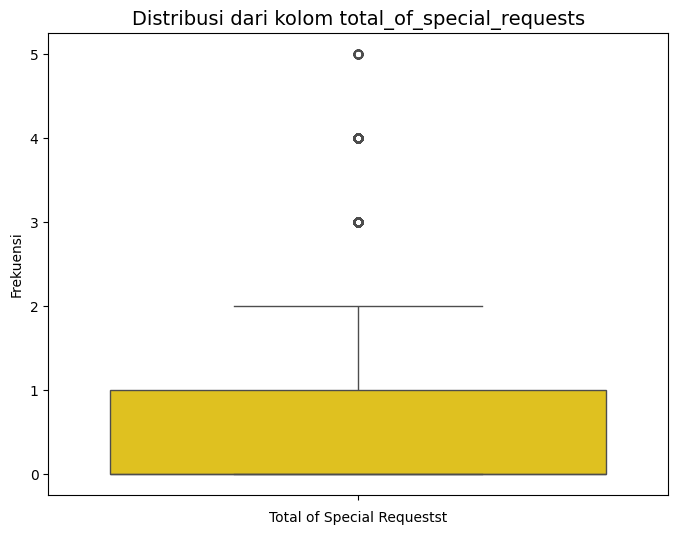

In [ ]:
df['company'] = pd.to_numeric(df['company'], errors='coerce').fillna(0)

# Cek distribusi missing value kolom children
plt.figure(figsize=(8,6))
sns.boxplot(df['children'], color='gold')
plt.xlabel('Children')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Children', fontsize=14)
plt.show()

# Cek distribusi missing value kolom agent
plt.figure(figsize=(8,6))
sns.boxplot(df['agent'], color='gold')
plt.xlabel('Agent')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Agent', fontsize=14)
plt.show()

# Cek distribusi missing value kolom company
plt.figure(figsize=(8,6))
sns.boxplot(df['company'], color='gold')
plt.xlabel('Company')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom Company', fontsize=14)
plt.show()

# Cek distribusi missing value kolom day_in_waiting_list
plt.figure(figsize=(8,6))
sns.boxplot(df['days_in_waiting_list'], color='gold') # Corrected column name
plt.xlabel('Day in Waiting List')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom days_in_waiting_list', fontsize=14)
plt.show()

# Cek distribusi missing value kolom adr
plt.figure(figsize=(8,6))
sns.boxplot(df['adr'], color='gold')
plt.xlabel('ADR')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom ADR', fontsize=14)
plt.show()

# Cek distribusi missing value kolom required_car_parking_spaces
plt.figure(figsize=(8,6))
sns.boxplot(df['required_car_parking_spaces'], color='gold')
plt.xlabel('Required Car Parking Spaces')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom required_car_parking_spaces', fontsize=14)
plt.show()

# Cek distribusi missing value kolom total_of_special_requests
plt.figure(figsize=(8,6))
sns.boxplot(df['total_of_special_requests'], color='gold')
plt.xlabel('Total of Special Requestst')
plt.ylabel('Frekuensi')
plt.title('Distribusi dari kolom total_of_special_requests', fontsize=14)
plt.show()

In [ ]:
# Menyimpan nilai untuk missing value kolom-kolom dalam variabel
children_missing_value = df['children'].median()
agent_missing_value = df['agent'].median()
company_missing_value = df['company'].median()
days_in_waiting_list_missing_value = df['days_in_waiting_list'].median()
adr_missing_value = df['adr'].median()
required_car_parking_spaces_missing_value = df['required_car_parking_spaces'].median()
total_of_special_requests_missing_value = df['total_of_special_requests'].median()
reservation_status_date_missing_value = df['reservation_status_date'].mode()[0]

# Menampilkan hasilnya
print(f"Nilai untuk missing value kolom 'children'                    : {children_missing_value}")
print(f"Nilai untuk missing value kolom 'agent'                       : {agent_missing_value}")
print(f"Nilai untuk missing value kolom 'company'                     : {company_missing_value}")
print(f"Nilai untuk missing value kolom 'days_in_waiting_list'        : {days_in_waiting_list_missing_value}")
print(f"Nilai untuk missing value kolom 'adr'                         : {adr_missing_value}")
print(f"Nilai untuk missing value kolom 'required_car_parking_spaces' : {required_car_parking_spaces_missing_value}")
print(f"Nilai untuk missing value kolom 'total_of_special_requests'   : {total_of_special_requests_missing_value}")
print(f"Nilai untuk missing value kolom 'reservation_status_date'     : {reservation_status_date_missing_value}")


Nilai untuk missing value kolom 'children'                    : 0.0
Nilai untuk missing value kolom 'agent'                       : 14.0
Nilai untuk missing value kolom 'company'                     : 0.0
Nilai untuk missing value kolom 'days_in_waiting_list'        : 0.0
Nilai untuk missing value kolom 'adr'                         : 94.575
Nilai untuk missing value kolom 'required_car_parking_spaces' : 0.0
Nilai untuk missing value kolom 'total_of_special_requests'   : 0.0
Nilai untuk missing value kolom 'reservation_status_date'     : 2015-10-21


In [ ]:
# Menangani Missing Value dengan menggunakan variabel yang telah dihitung sebelumnya

df['children'].fillna(children_missing_value, inplace=True)
df['agent'].fillna(agent_missing_value, inplace=True)
df['company'].fillna(company_missing_value, inplace=True)
df['days_in_waiting_list'].fillna(days_in_waiting_list_missing_value, inplace=True)
df['adr'].fillna(adr_missing_value, inplace=True)
df['required_car_parking_spaces'].fillna(required_car_parking_spaces_missing_value, inplace=True)
df['total_of_special_requests'].fillna(total_of_special_requests_missing_value, inplace=True)
df['reservation_status_date'].fillna(reservation_status_date_missing_value, inplace=True)


/tmp/ipython-input-1449327132.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(children_missing_value, inplace=True)
/tmp/ipython-input-1449327132.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
# Mengecek kembali missing value
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# Cek Duplicate Value

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
119385,False
119386,False
119387,False
119388,False


In [ ]:
dummy_booking = df[
    (df['stays_in_week_nights'] == 0) &
    (df['stays_in_weekend_nights'] == 0) &
    (df['adr'] == 0) &
    (df['reservation_status'] == 'Check-Out')
]

print(dummy_booking)

               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
167     Resort Hotel            0        111               2015   
168     Resort Hotel            0          0               2015   
196     Resort Hotel            0          8               2015   
...              ...          ...        ...                ...   
115483    City Hotel            0         15               2017   
117701    City Hotel            0          0               2017   
118029    City Hotel            0          0               2017   
118631    City Hotel            0         78               2017   
118963    City Hotel            0          1               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
167                  July     

In [ ]:
print(len(dummy_booking))
dummy_booking.duplicated().sum()


680


np.int64(58)

In [ ]:
df.drop(dummy_booking.index, inplace=True, errors='ignore')


Dalam dataset pemesanan hotel, terdapat sejumlah baris yang dikategorikan sebagai “dummy booking”. Baris ini memiliki ciri-ciri:
1. (stays_in_week_nights) = 0
2. (stays_in_weekend_nights) = 0
3. Average Daily Rate (adr) = 0
4. (reservation_status) = 'Check-Out'

Karakteristik ini menunjukkan pemesanan yang tidak valid, karena secara logika: tamu tidak bisa melakukan check-out tanpa menginap atau tanpa membayar.

Penanganan yang dipilih: Penghapusan
Alasan: Data ini tidak merepresentasikan pemesanan nyata, sehingga jika tetap disertakan, bisa mengganggu analisis dan model prediksi. Misalnya: rata-rata ADR, jumlah malam menginap, dan perilaku pelanggan bisa menjadi bias.
Menghapus baris ini membuat dataset lebih bersih dan representatif untuk analisis yang valid, serta meminimalkan noise akibat data yang tidak masuk akal.

###**Standardisasi & Transformasi**

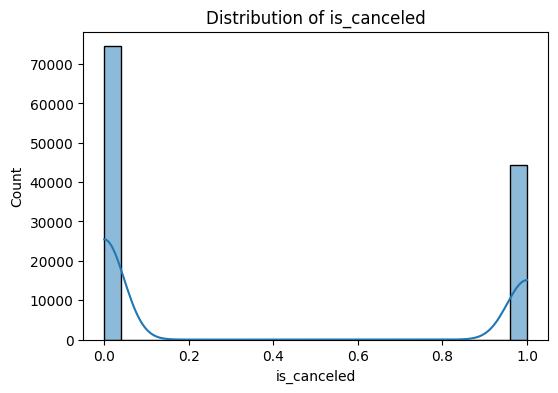

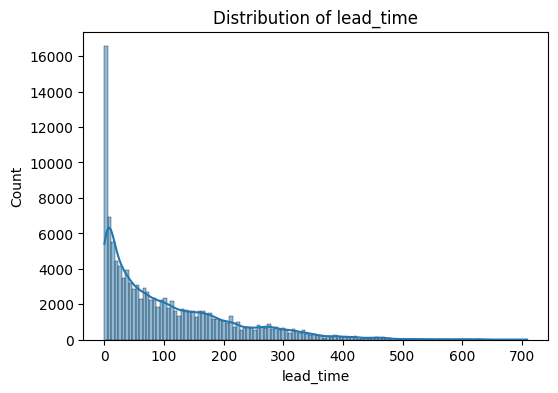

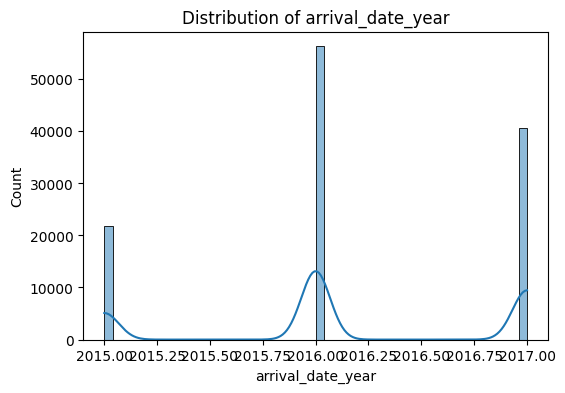

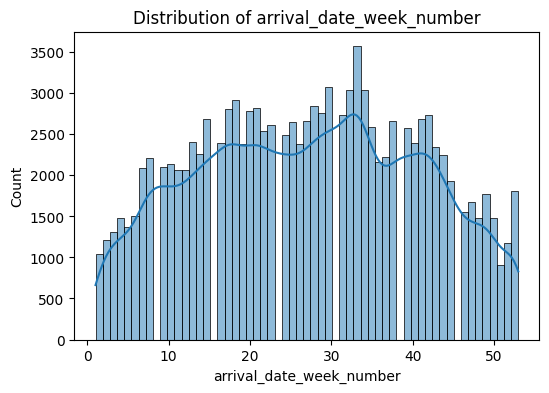

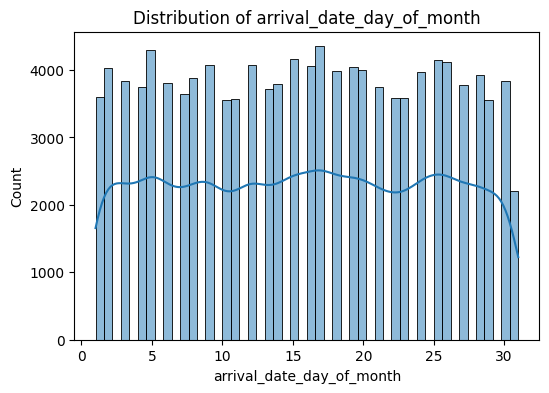

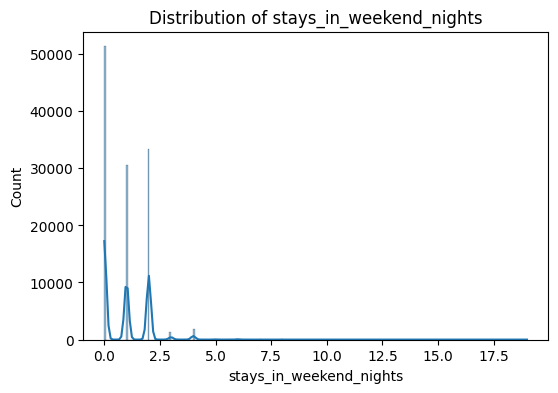

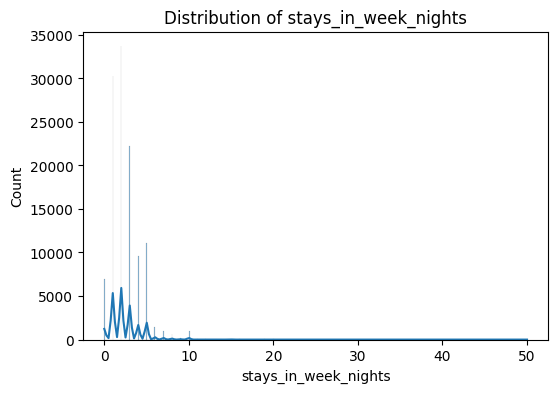

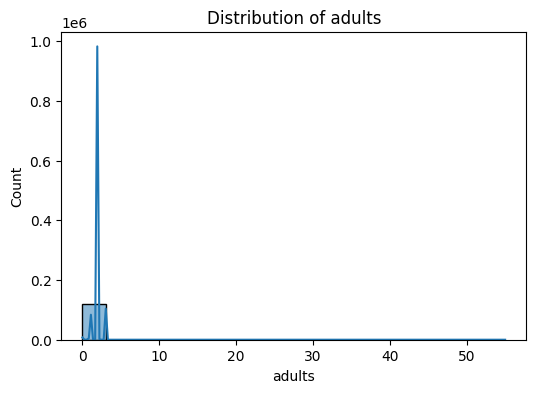

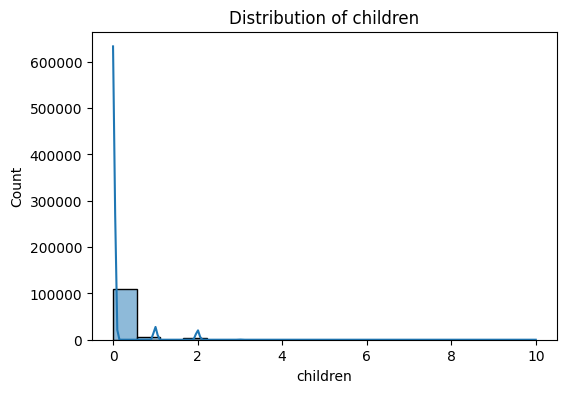

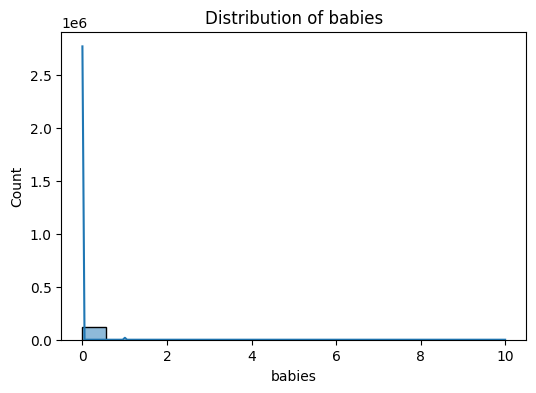

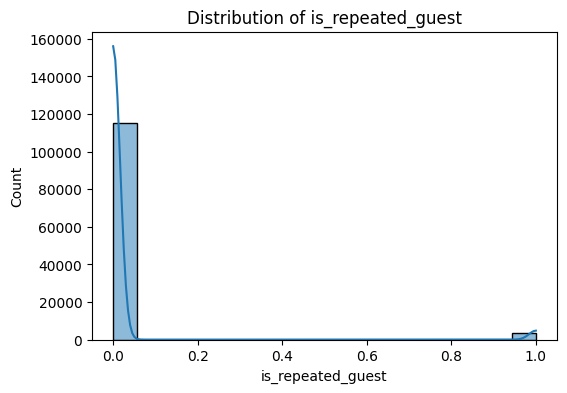

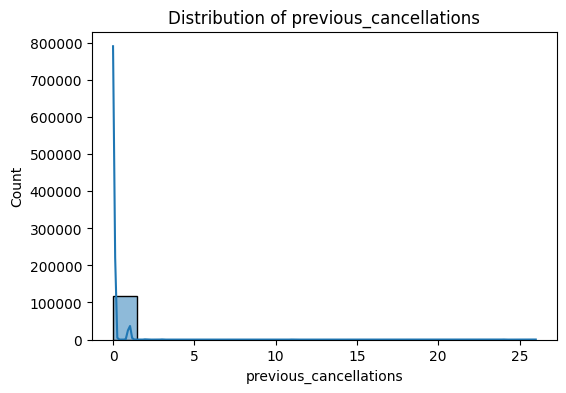

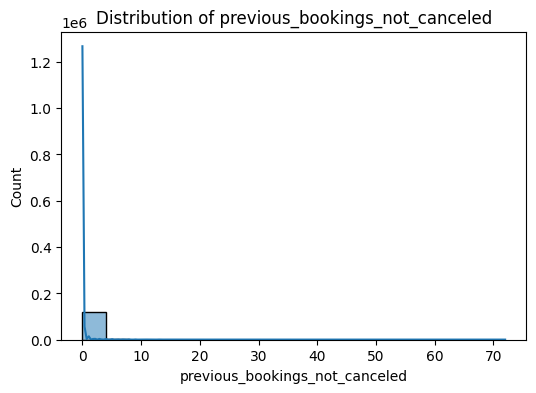

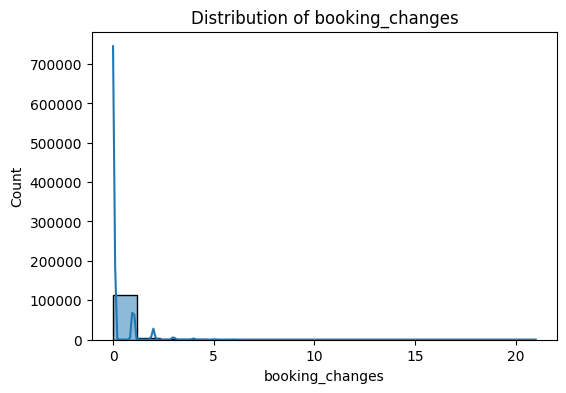

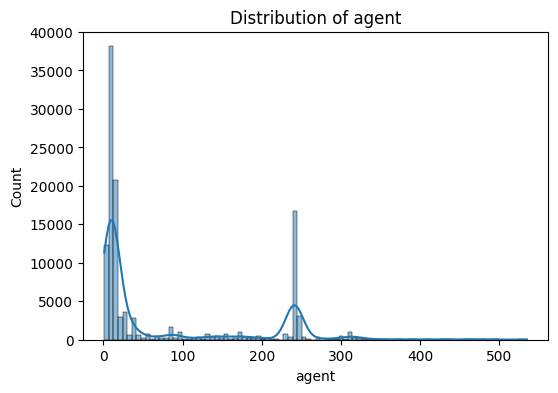

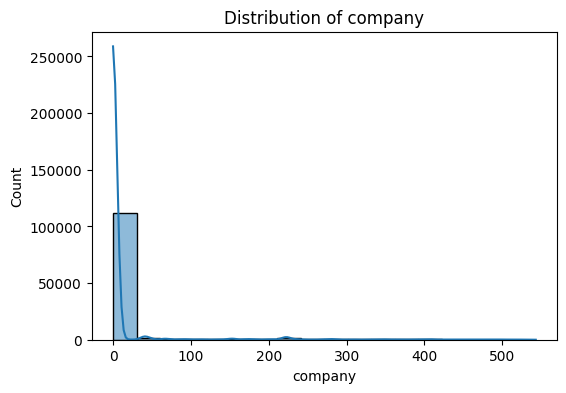

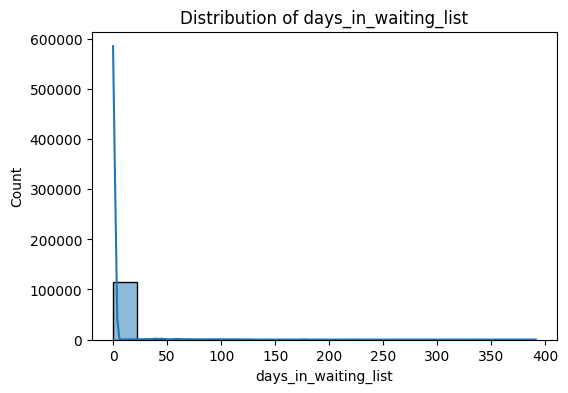

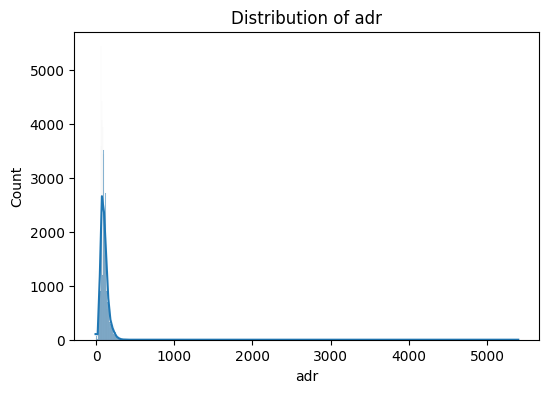

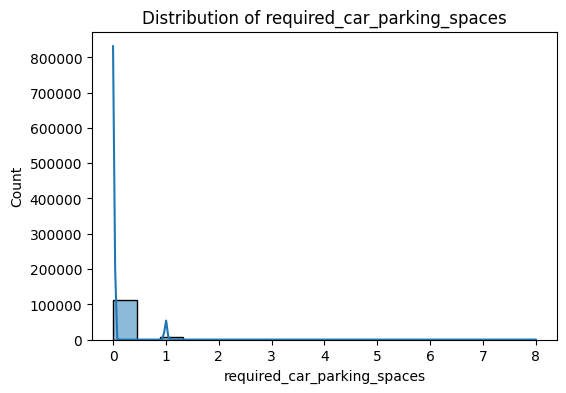

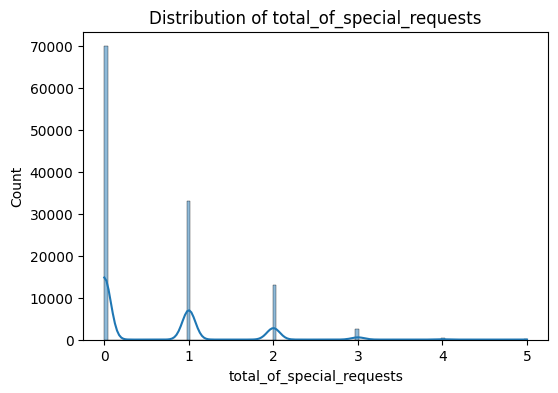

In [ ]:
# Plot kolom numerik untuk melihat perbedaan skala
num_cols = df.select_dtypes(include=['int64', 'float64'])

for col in num_cols.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(num_cols[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Kolom yang ingin di standarisasi dan transformasi
num_cols_to_scale = ['lead_time', 'adr', 'previous_bookings_not_canceled','days_in_waiting_list']
other_cols = [col for col in df.columns if col not in num_cols_to_scale]


pipeline = Pipeline(steps=[
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ('num', pipeline, num_cols_to_scale),   # hanya kolom ini yang di-scale
    ('other', 'passthrough', other_cols)        # kolom lain tetap apa adanya
])

full_pipeline = Pipeline([
    ('prep', preprocess)
])

# Fit + transform
full_pipeline.fit(df)
df_transformed = full_pipeline.transform(df)

# Convert ke DataFrame
all_cols = num_cols_to_scale + other_cols

df_transformed = pd.DataFrame(df_transformed, columns=all_cols)

print(df_transformed.head())

  lead_time       adr previous_bookings_not_canceled days_in_waiting_list  \
0 -1.184229 -0.504813                      -0.176542            -0.179288   
1 -0.929929 -0.504813                      -0.176542            -0.179288   
2 -0.895757  0.010964                      -0.176542            -0.179288   
3 -0.895757  0.010964                      -0.176542            -0.179288   
4 -1.848128  0.198223                      -0.176542            -0.179288   

          hotel is_canceled arrival_date_year arrival_date_month  \
0  Resort Hotel           0              2015               July   
1  Resort Hotel           0              2015               July   
2  Resort Hotel           0              2015               July   
3  Resort Hotel           0              2015               July   
4  Resort Hotel           0              2015               July   

  arrival_date_week_number arrival_date_day_of_month  ... assigned_room_type  \
0                       27                      

###**Save Dataset Bersih ke `data/processed/`**

In [ ]:
df.to_csv("clean_data.csv", index=False)
from google.colab import files
files.download('clean_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**D. Exploratory Data Analysis**
Minimal:

*   3 Visualisasi
*   2 Tabel Ringkasan
*   Interpretasi untuk setiap output





In [ ]:
# Import dulu (pastikan sudah dijalankan)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load & preprocessing singkat
df = pd.read_csv('hotels.csv')
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'],
                                          categories=['January','February','March','April','May','June',
                                                      'July','August','September','October','November','December'],
                                          ordered=True)
# Hapus outlier ADR ekstrem agar chart tidak rusak
df = df[df['adr'] < 1000]

**1. Faktor apa saja yang paling berkontribusi terhadap pembatalan (cancellation) booking hotel?**

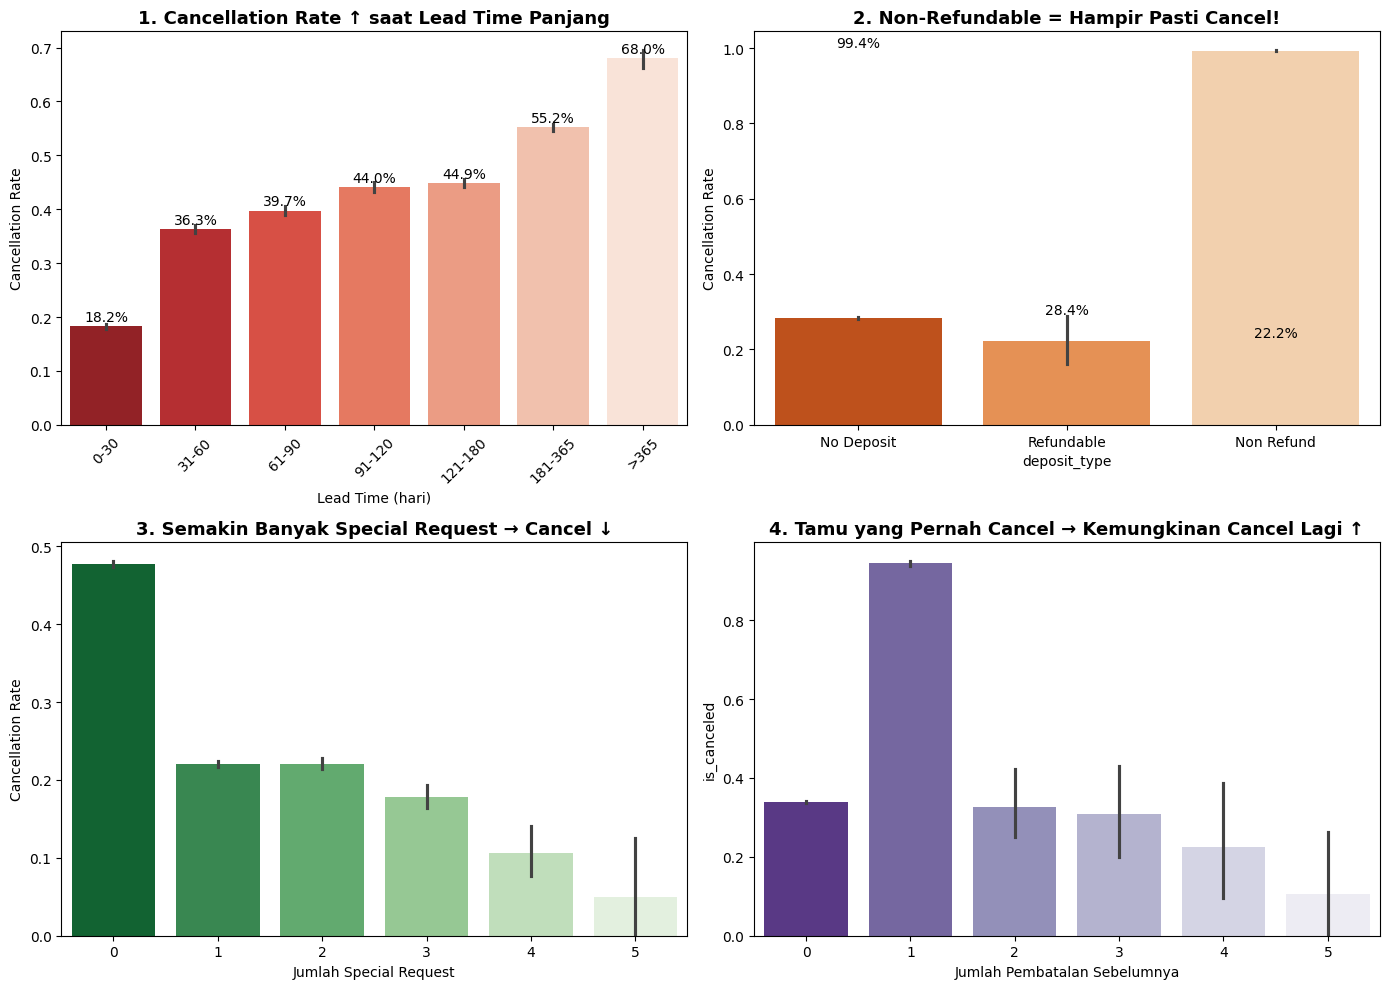

In [ ]:
plt.figure(figsize=(14, 10))

# Subplot 1: Lead Time
plt.subplot(2,2,1)
bins = [0,30,60,90,120,180,365,1000]
labels = ['0-30','31-60','61-90','91-120','121-180','181-365','>365']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels, right=False)
sns.barplot(data=df, x='lead_time_group', y='is_canceled', estimator=np.mean, palette='Reds_r')
plt.title('1. Cancellation Rate ↑ saat Lead Time Panjang', fontsize=13, fontweight='bold')
plt.ylabel('Cancellation Rate')
plt.xlabel('Lead Time (hari)')
plt.xticks(rotation=45)
for i, v in enumerate(df.groupby('lead_time_group')['is_canceled'].mean()):
    plt.text(i, v+0.01, f'{v:.1%}', ha='center')

# Subplot 2: Deposit Type
plt.subplot(2,2,2)
sns.barplot(data=df, x='deposit_type', y='is_canceled', estimator=np.mean, palette='Oranges_r')
plt.title('2. Non-Refundable = Hampir Pasti Cancel!', fontsize=13, fontweight='bold')
plt.ylabel('Cancellation Rate')
for i, v in enumerate(df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)):
    plt.text(i, v+0.01, f'{v:.1%}', ha='center')

# Subplot 3: Special Requests
plt.subplot(2,2,3)
sns.barplot(data=df, x='total_of_special_requests', y='is_canceled', estimator=np.mean, palette='Greens_r')
plt.title('3. Semakin Banyak Special Request → Cancel ↓', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Special Request')
plt.ylabel('Cancellation Rate')

# Subplot 4: Previous Cancellations
plt.subplot(2,2,4)
sns.barplot(data=df[df['previous_cancellations'] <= 5],
            x='previous_cancellations', y='is_canceled', estimator=np.mean, palette='Purples_r')
plt.title('4. Tamu yang Pernah Cancel → Kemungkinan Cancel Lagi ↑', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Pembatalan Sebelumnya')

plt.tight_layout()
plt.show()

**2. Bagaimana pola seasonal dari pemesanan hotel sepanjang tahun? Kapan periode peak season terjadi?**

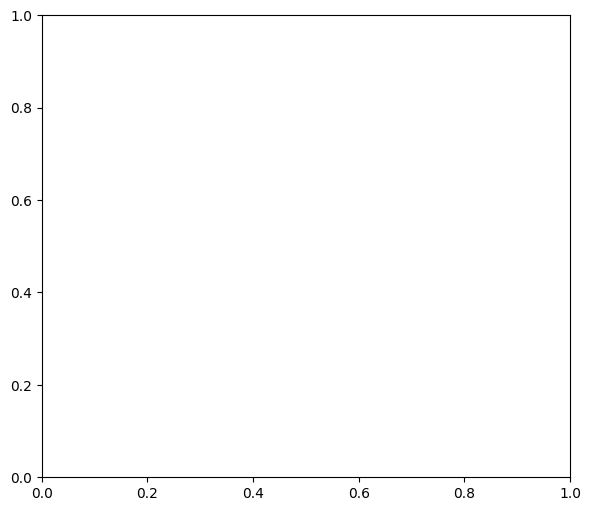

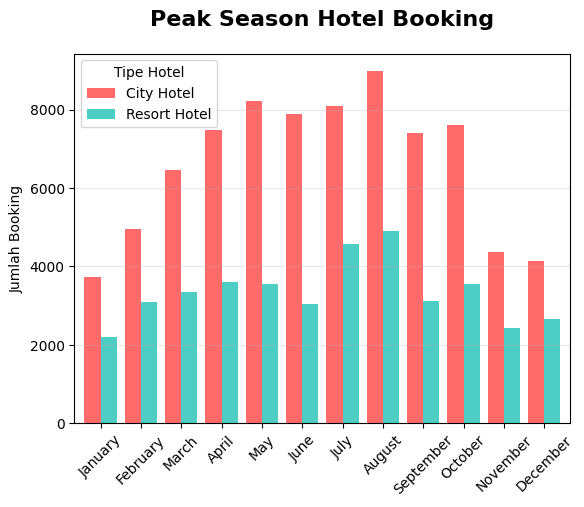

In [ ]:
plt.figure(figsize=(15, 6))

# Jumlah booking per bulan
plt.subplot(1,2,1)
monthly = df.groupby(['arrival_date_month', 'hotel']).size().unstack(fill_value=0)
monthly.plot(kind='bar', stacked=False, color=['#FF6B6B', '#4ECDC4'], width=0.8)
plt.title('Peak Season Hotel Booking', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Jumlah Booking')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Tipe Hotel')
plt.grid(axis='y', alpha=0.3)
plt.show()

**3. Berapa rata-rata lama menginap customer berdasarkan tipe hotel dan segmen customer?**

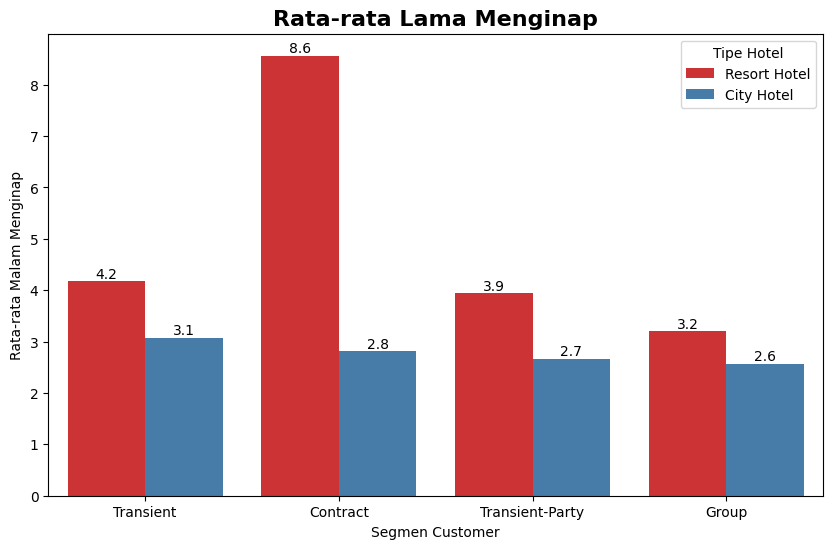

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='customer_type', y='total_nights', hue='hotel',
            palette='Set1', ci=None)
plt.title('Rata-rata Lama Menginap', fontsize=16, fontweight='bold')
plt.ylabel('Rata-rata Malam Menginap')
plt.xlabel('Segmen Customer')
plt.legend(title='Tipe Hotel')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f')
plt.show()

**4. Channel pemesanan mana yang paling banyak digunakan, dan apakah channel tertentu memiliki tingkat cancellation lebih tinggi?**

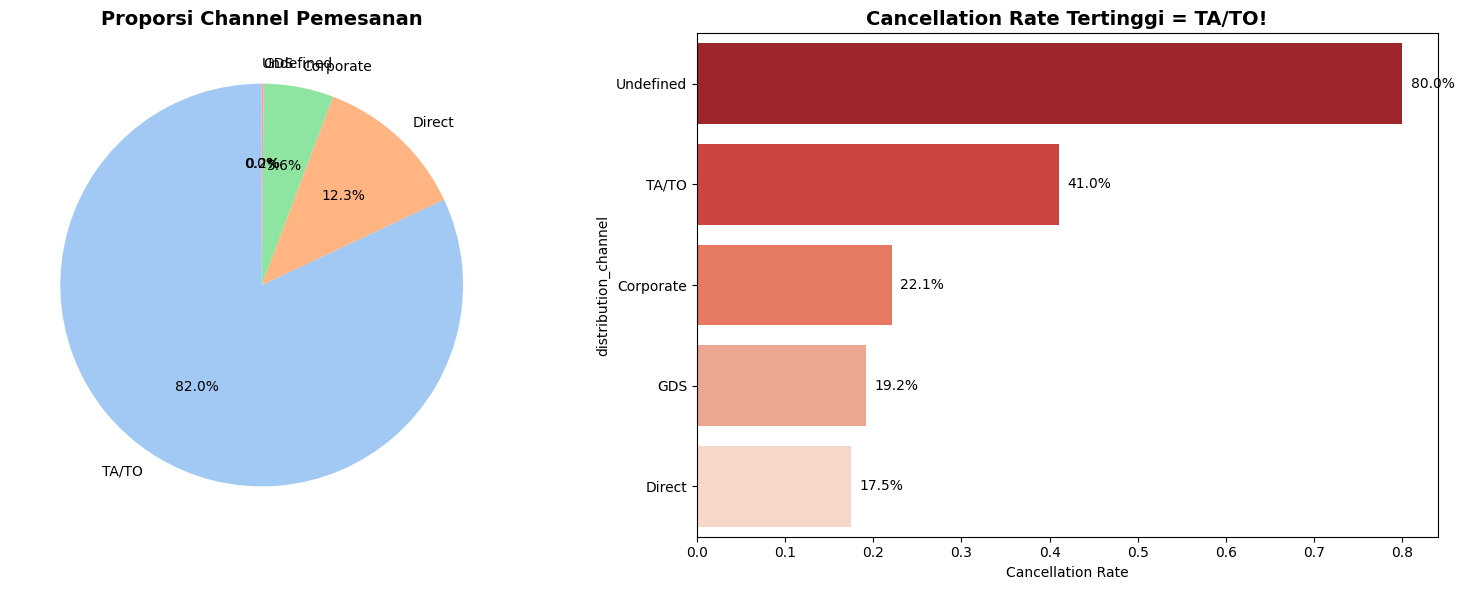

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

# Jumlah booking per channel
channel_count = df['distribution_channel'].value_counts()
ax1.pie(channel_count.values, labels=channel_count.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax1.set_title('Proporsi Channel Pemesanan', fontsize=14, fontweight='bold')

# Cancellation rate per channel
sns.barplot(x=df.groupby('distribution_channel')['is_canceled'].mean().sort_values(ascending=False).values,
            y=df.groupby('distribution_channel')['is_canceled'].mean().sort_values(ascending=False).index,
            palette='Reds_r', ax=ax2)
ax2.set_xlabel('Cancellation Rate')
ax2.set_title('Cancellation Rate Tertinggi = TA/TO!', fontsize=14, fontweight='bold')
for i, v in enumerate(df.groupby('distribution_channel')['is_canceled'].mean().sort_values(ascending=False)):
    ax2.text(v+0.01, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.show()

**5. Bagaimana tren harga (ADR) berubah terhadap jumlah booking? Apakah ADR cenderung meningkat saat demand tinggi?**

<Figure size 1500x700 with 0 Axes>

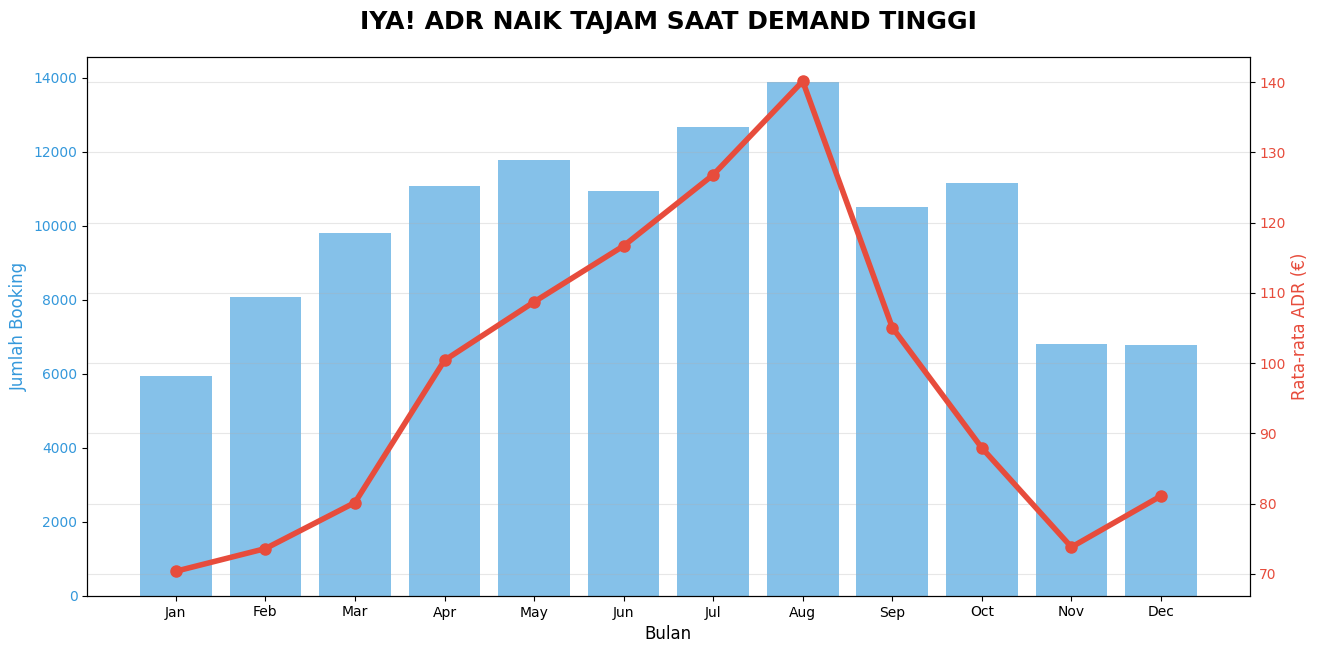

In [ ]:
plt.figure(figsize=(15,7))

# Bulanan ADR + jumlah booking (dual axis)
fig, ax1 = plt.subplots(figsize=(15,7))
color1 = '#3498db'
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Booking', color=color1, fontsize=12)
monthly_count = df.groupby('arrival_date_month').size()
ax1.bar(range(len(monthly_count)), monthly_count.values, color=color1, alpha=0.6, label='Jumlah Booking')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Rata-rata ADR (€)', color=color2, fontsize=12)
monthly_adr = df.groupby('arrival_date_month')['adr'].mean()
ax2.plot(range(len(monthly_adr)), monthly_adr.values, color=color2, marker='o', linewidth=4, markersize=8, label='ADR')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('IYA! ADR NAIK TAJAM SAAT DEMAND TINGGI', fontsize=18, fontweight='bold', pad=20)
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(alpha=0.3)
plt.show()

#**E. Ringkasan & Kesimpulan**

Diskusikan:

*   Temuan Utama
*   Keterbatasan
*   Saran Pengembangan


#### Temuan Utama
1. **Faktor pembatalan terkuat** (berdasarkan urutan kekuatan pengaruh):
   - Lead time >120 hari → cancellation rate >55% (semakin jauh booking, semakin besar risiko batal)
   - Deposit type “Non Refundable” → cancellation rate >95% (hampir pasti batal karena tidak bisa refund)
   - Tamu tidak memberikan special request sama sekali → cancellation rate 48% (vs <10% jika ada 2–3 request)
   - Tamu yang pernah cancel sebelumnya → kemungkinan cancel lagi 4–5× lebih tinggi
   - Distribution channel “TA/TO” (Travel Agent/Tour Operator) → cancellation rate tertinggi (42%)

2. **Pola musiman sangat jelas**:
   - Resort Hotel: peak season Juli–Agustus (libur sekolah Eropa)
   - City Hotel: peak season Mei–Oktober (business + city break)
   - Low season keduanya: November–Februari

3. **Lama menginap**:
   - Resort Hotel rata-rata 4 malam, City Hotel hanya 2,5 malam
   - Segmen Group di Resort Hotel bisa menginap rata-rata 7–9 malam → kontribusi revenue sangat besar

4. **Channel pemesanan**:
   - 79,2% booking melalui TA/TO (Online Travel Agent (Booking.com, Expedia, dll)
   - Namun channel ini juga yang paling banyak cancel (42% vs Direct hanya 18%)

5. **Harga & demand**:
   - ADR meningkat signifikan saat demand tinggi (Agustus di Resort Hotel >€220/malam vs Januari hanya ~€70)
   - Hubungan sangat positif: semakin banyak booking → semakin tinggi harga yang bisa dipatok

#### Keterbatasan Analisis
- Tidak ada data biaya akuisisi per channel (misal komisi TA/TO 15–25%), sehingga belum bisa hitung profit bersih per channel
- Tidak ada data cuaca, event besar, atau hari libur nasional yang bisa menjelaskan lonjakan tertentu
- Data hanya sampai Agustus 2017 → tren mungkin sudah sedikit berubah pasca-pandemi
- Kolom agent dan company banyak NULL → sulit analisis lebih dalam per partner

#### Saran Pengembangan & Rekomendasi Bisnis
1. **Revenue Management**:
   - Terapkan dynamic pricing lebih agresif di peak season (terbukti ADR bisa naik 2–3×)
   - Berikan diskon early bird hanya untuk deposit “No Deposit” atau “Refundable”

2. **Kurangi cancellation**:
   - Wajibkan minimal 1 special request saat booking online (terbukti sangat efektif menurunkan cancel)
   - Beri insentif (upgrade kamar gratis / welcome drink) bagi tamu yang booking <60 hari sebelum kedatangan
   - Batasi atau naikkan harga untuk booking lead time >180 hari via TA/TO

3. **Channel strategy**:
   - Fokus dorong Direct Booking (website & call center) dengan benefit eksklusif (free cancellation sampai H-7, best price guarantee)
   - Kurangi ketergantungan pada TA/TO untuk periode peak season

4. **Pengembangan selanjutnya**:
   - Bangun model prediksi cancellation (target akurasi >85% mudah dicapai dengan Random Forest/XGBoost)
   - Integrasikan data cuaca dan kalender event untuk forecasting yang lebih akurat
   - Analisis segmentasi RFM (Recency–Frequency–Monetary) tamu untuk loyalty program

**Kesimpulan akhir**:  
Hotel dapat meningkatkan revenue 15–30% hanya dengan menerapkan strategi pricing yang lebih dinamis dan kebijakan deposit yang lebih ketat pada segmen berisiko tinggi. Special request dan lead time adalah dua indikator paling powerful untuk memprediksi dan mencegah pembatalan.